# Real vs. Manipulated Face Classifier

**Aim:** Build a CNN that tells real, unaltered faces apart from digitally manipulated ones (swapped eyes/nose/mouth), using transfer learning, Error Level Analysis, and Grad-CAM.

**Why this project:** Face manipulation detection is directly relevant to platform trust & safety and identity verification. These fakes are subtle, localized edits — genuinely hard to catch by eye, which makes the model's job (and the story you can tell about it) more interesting.

**Dataset:** [Real and Fake Face Detection (Kaggle, CIP Lab @ Yonsei)](https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection) — 1,081 real faces, 960 manipulated faces (~215MB total). Fakes are graded by difficulty (`easy_`, `mid_`, `hard_` in the filename).

## Phase 1: Setup & Data Loading

In [1]:
import os
import io
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image, ImageChops
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.random.set_seed(42)
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [2]:
DATA_DIR = "real_and_fake_face"   # adjust to wherever you extract the download

real_dir = os.path.join(DATA_DIR, "training_real")
fake_dir = os.path.join(DATA_DIR, "training_fake")

real_paths = [os.path.join(real_dir, f) for f in os.listdir(real_dir)]
fake_paths = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir)]

paths = real_paths + fake_paths
labels = [1] * len(real_paths) + [0] * len(fake_paths)   # 1 = real, 0 = fake

print(f"Real: {len(real_paths)}, Fake: {len(fake_paths)}")


Real: 1081, Fake: 960


In [3]:
# 70% train, 15% val, 15% test -- stratified so class balance holds in each split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.3, stratify=labels, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"Train: {len(train_paths)}  Val: {len(val_paths)}  Test: {len(test_paths)}")


Train: 1428  Val: 306  Test: 307


## Phase 2: Data Exploration
Goal: check class balance held after splitting, and actually look at the images before building anything.

In [4]:
for name, split_labels in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    real_pct = 100 * sum(split_labels) / len(split_labels)
    print(f"{name}: {len(split_labels)} images, {real_pct:.1f}% real")


Train: 1428 images, 52.9% real
Val: 306 images, 52.9% real
Test: 307 images, 53.1% real


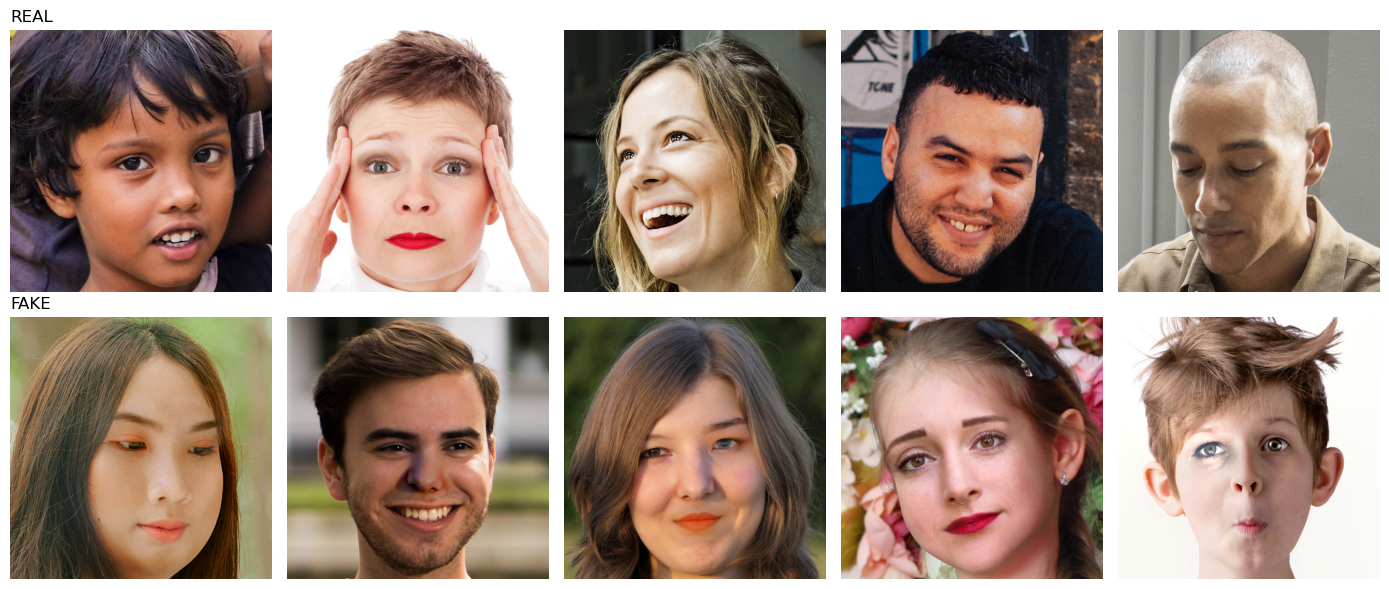

In [5]:
# Look at a few real vs fake images side by side
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, path in enumerate(real_paths[:5]):
    axes[0, i].imshow(plt.imread(path))
    axes[0, i].axis("off")
axes[0, 0].set_title("REAL", loc="left", fontsize=12)

for i, path in enumerate(fake_paths[:5]):
    axes[1, i].imshow(plt.imread(path))
    axes[1, i].axis("off")
axes[1, 0].set_title("FAKE", loc="left", fontsize=12)
plt.tight_layout()
plt.show()


**Bonus check:** fake filenames encode difficulty (`easy_`, `mid_`, `hard_`). Let's see the breakdown and compare an easy fake to a hard one — this tells you upfront how tough the task really is.

Counter({'mid': 480, 'easy': 240, 'hard': 240})


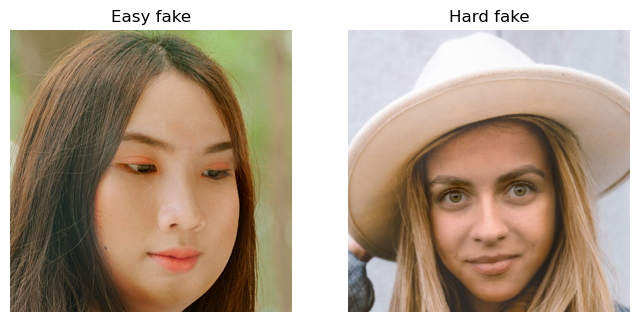

In [6]:
from collections import Counter

difficulty = [os.path.basename(p).split("_")[0] for p in fake_paths]
print(Counter(difficulty))

easy_example = next(p for p in fake_paths if "easy_" in os.path.basename(p))
hard_example = next(p for p in fake_paths if "hard_" in os.path.basename(p))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(plt.imread(easy_example)); axes[0].set_title("Easy fake"); axes[0].axis("off")
axes[1].imshow(plt.imread(hard_example)); axes[1].set_title("Hard fake"); axes[1].axis("off")
plt.show()


## Phase 3: Error Level Analysis (ELA) Preprocessing

**Why:** the edits in this dataset are localized Photoshop splices. A splice pastes pixels from a different source image into the original — and that pasted region usually has a *different JPEG compression history* than the rest of the photo. Error Level Analysis makes that difference visible: re-save the image at a known JPEG quality, then take the pixel-wise difference from the original. Untouched regions barely change; edited regions light up.

Instead of feeding the model raw pixels (where this compression mismatch is nearly invisible), we feed it the ELA map — turning a hard, near-invisible task into an easier, more visible one.

In [7]:
def compute_ela(path, quality=90):
    original = Image.open(path).convert("RGB")

    buffer = io.BytesIO()
    original.save(buffer, "JPEG", quality=quality)
    buffer.seek(0)
    resaved = Image.open(buffer)

    diff = ImageChops.difference(original, resaved)
    max_diff = max(ex[1] for ex in diff.getextrema()) or 1   # avoid divide-by-zero
    scale = 255.0 / max_diff
    return diff.point(lambda p: p * scale)


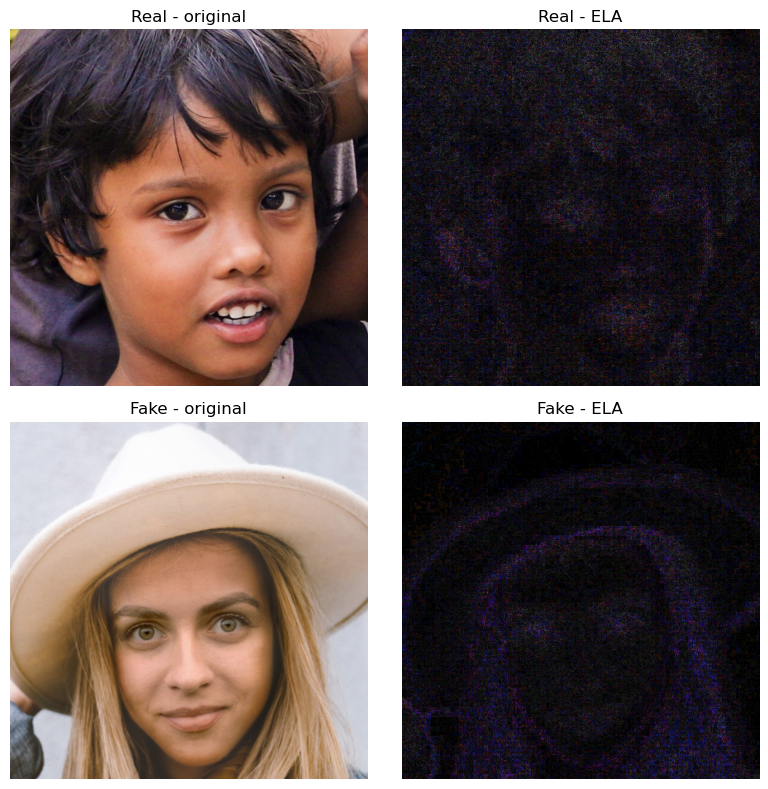

In [8]:
# Sanity check: does ELA actually highlight anything different between real and fake?
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0, 0].imshow(Image.open(real_paths[0])); axes[0, 0].set_title("Real - original"); axes[0, 0].axis("off")
axes[0, 1].imshow(compute_ela(real_paths[0])); axes[0, 1].set_title("Real - ELA"); axes[0, 1].axis("off")
axes[1, 0].imshow(Image.open(hard_example)); axes[1, 0].set_title("Fake - original"); axes[1, 0].axis("off")
axes[1, 1].imshow(compute_ela(hard_example)); axes[1, 1].set_title("Fake - ELA"); axes[1, 1].axis("off")
plt.tight_layout()
plt.show()


**What's happening next:** the dataset is small (~2,000 images), so rather than streaming from disk we just compute every ELA image once, resize it, and hold everything in memory as plain numpy arrays. Simpler code, and fast enough at this size.

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_ela_array(path):
    ela_img = compute_ela(path).resize(IMG_SIZE)
    return np.array(ela_img) / 255.0

def build_array(paths):
    return np.stack([load_ela_array(p) for p in paths]).astype("float32")

X_train, y_train = build_array(train_paths), np.array(train_labels)
X_val,   y_val   = build_array(val_paths),   np.array(val_labels)
X_test,  y_test  = build_array(test_paths),  np.array(test_labels)

print(X_train.shape, X_val.shape, X_test.shape)


(1428, 224, 224, 3) (306, 224, 224, 3) (307, 224, 224, 3)


In [10]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train), seed=42).batch(BATCH_SIZE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)


## Phase 4: Augmentation
Goal: add variety to the training data only (never to val/test) so the model doesn't just memorize the ~1,300 training images.

In [11]:
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
])
# Note: no brightness/contrast augmentation here -- those would distort the ELA signal itself

train_ds_aug = train_ds.map(lambda x, y: (augment(x, training=True), y))


## Phase 5: Build the Model (Transfer Learning)
Goal: use MobileNetV2, pretrained on ImageNet, as a starting point. We start with it **frozen** and train just a small head first, then unfreeze part of the backbone and fine-tune in Phase 6.

In [12]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet"
)
base_model.trainable = False   # freeze it -- we only train our own head first

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = layers.Rescaling(scale=2.0, offset=-1.0)(inputs)   # our images are [0,1], MobileNetV2 wants [-1,1]
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Phase 6: Training

**Stage 1 — train the head only (backbone frozen).**

In [13]:
weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weight_dict)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)

history = model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)


Class weights: {0: np.float64(1.0625), 1: np.float64(0.9444444444444444)}
Epoch 1/8


C:\Users\Abity\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 343ms/step - accuracy: 0.5007 - loss: 0.8008 - val_accuracy: 0.5196 - val_loss: 0.7364
Epoch 2/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 302ms/step - accuracy: 0.5511 - loss: 0.7358 - val_accuracy: 0.5621 - val_loss: 0.7012
Epoch 3/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 305ms/step - accuracy: 0.5574 - loss: 0.7343 - val_accuracy: 0.5294 - val_loss: 0.7163
Epoch 4/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 316ms/step - accuracy: 0.5763 - loss: 0.6911 - val_accuracy: 0.6209 - val_loss: 0.6599
Epoch 5/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 314ms/step - accuracy: 0.5917 - loss: 0.6847 - val_accuracy: 0.6536 - val_loss: 0.6478
Epoch 6/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 315ms/step - accuracy: 0.5910 - loss: 0.6842 - val_accuracy: 0.6471 - val_loss: 0.6467
Epoch 7/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 311ms/step - accuracy: 0.6176 - loss: 0.6631 - val_accuracy: 0.6111 - val_loss: 0.6606
Epoch 8/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 314ms/step - accuracy: 0.6232 - loss: 0.6703 - val_accuracy: 0.6176 - val

**Stage 2 — fine-tune.** Unfreeze the last block of MobileNetV2 and continue training at a much lower learning rate, so the backbone can adapt to the ELA input rather than relying on generic ImageNet features.

In [14]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

fine_tune_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_fine = model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=[fine_tune_early_stop],
)


Epoch 1/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 376ms/step - accuracy: 0.5574 - loss: 0.7126 - val_accuracy: 0.6242 - val_loss: 0.6495
Epoch 2/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 345ms/step - accuracy: 0.5959 - loss: 0.6797 - val_accuracy: 0.6275 - val_loss: 0.6517
Epoch 3/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 346ms/step - accuracy: 0.6211 - loss: 0.6560 - val_accuracy: 0.6438 - val_loss: 0.6492
Epoch 4/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 340ms/step - accuracy: 0.6275 - loss: 0.6507 - val_accuracy: 0.6405 - val_loss: 0.6465
Epoch 5/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 346ms/step - accuracy: 0.6534 - loss: 0.6269 - val_accuracy: 0.6340 - val_loss: 0.6452
Epoch 6/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 343ms/step - accuracy: 0.6352 - loss: 0.6277 - val_accuracy: 0.6176 - val_loss: 0.6468
Epoch 7/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 342ms/step - accuracy: 0.6807 - loss: 0.5963 - val_accuracy: 0.6373 - val_loss: 0.6455
Epoch 8/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 346ms/step - accuracy: 0.6604 - loss: 0.6031 - val_accu

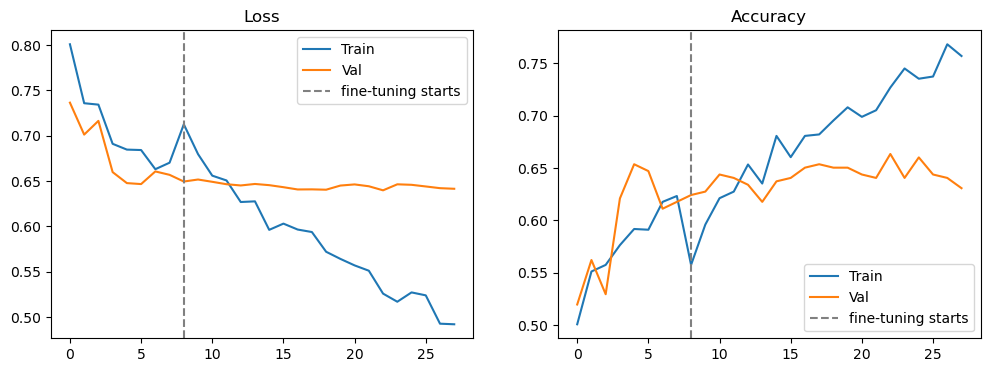

In [15]:
loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]
fine_tune_start = len(history.history["loss"])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(loss, label="Train")
plt.plot(val_loss, label="Val")
plt.axvline(fine_tune_start, color="gray", linestyle="--", label="fine-tuning starts")
plt.title("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc, label="Train")
plt.plot(val_acc, label="Val")
plt.axvline(fine_tune_start, color="gray", linestyle="--", label="fine-tuning starts")
plt.title("Accuracy"); plt.legend()
plt.show()


## Phase 7: Evaluation
Goal: measure real performance on the held-out test set, per class -- not just overall accuracy.

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 325ms/step
              precision    recall  f1-score   support

        FAKE       0.60      0.75      0.67       144
        REAL       0.72      0.56      0.63       163

    accuracy                           0.65       307
   macro avg       0.66      0.65      0.65       307
weighted avg       0.66      0.65      0.65       307



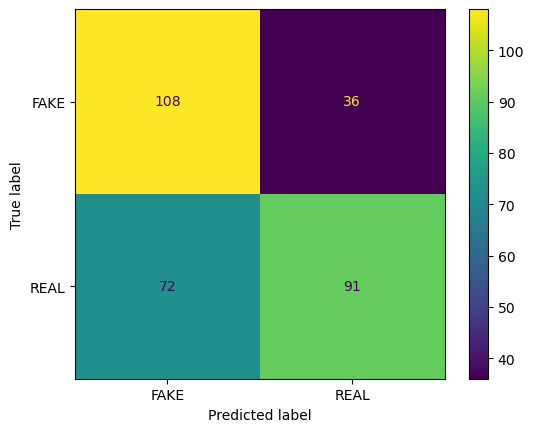

In [16]:
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["FAKE", "REAL"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["FAKE", "REAL"]).plot()
plt.show()


**Bonus — accuracy by fake difficulty:** does the model actually struggle more on `hard_` fakes than `easy_` ones?

In [17]:
results_by_difficulty = {"easy": [], "mid": [], "hard": [], "real": []}

for path, true_label, pred_label in zip(test_paths, y_test, y_pred):
    correct = int(true_label == pred_label)
    if true_label == 1:
        results_by_difficulty["real"].append(correct)
    else:
        diff = os.path.basename(path).split("_")[0]
        results_by_difficulty[diff].append(correct)

for group, correct_list in results_by_difficulty.items():
    if correct_list:
        acc = 100 * sum(correct_list) / len(correct_list)
        print(f"{group}: {acc:.1f}% accuracy (n={len(correct_list)})")


easy: 71.4% accuracy (n=35)
mid: 78.9% accuracy (n=76)
hard: 69.7% accuracy (n=33)
real: 55.8% accuracy (n=163)


## Phase 8: Grad-CAM — What Is the Model Looking At?
Goal: visualize which regions of the ELA map pushed the model toward "real" or "fake".

In [20]:
def grad_cam(model, img_array):
    # Build a model straight from MobileNetV2's own input/output (stays internally consistent --
    # fetching a nested submodel's layer .output AFTER it's been called inside another model
    # loses its connection to that outer model's input in newer Keras versions).
    base = next(l for l in model.layers if isinstance(l, tf.keras.Model))
    conv_model = tf.keras.Model(base.input, base.get_layer("out_relu").output)

    dense_layer = model.layers[-1]   

    x = tf.convert_to_tensor(img_array[np.newaxis, ...] * 2.0 - 1.0) 

    with tf.GradientTape() as tape:
        conv_output = conv_model(x, training=False)
        pooled = tf.reduce_mean(conv_output, axis=(1, 2))  
        prediction = dense_layer(pooled)                    
        loss = prediction[:, 0]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_output[0] * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), float(prediction[0, 0])

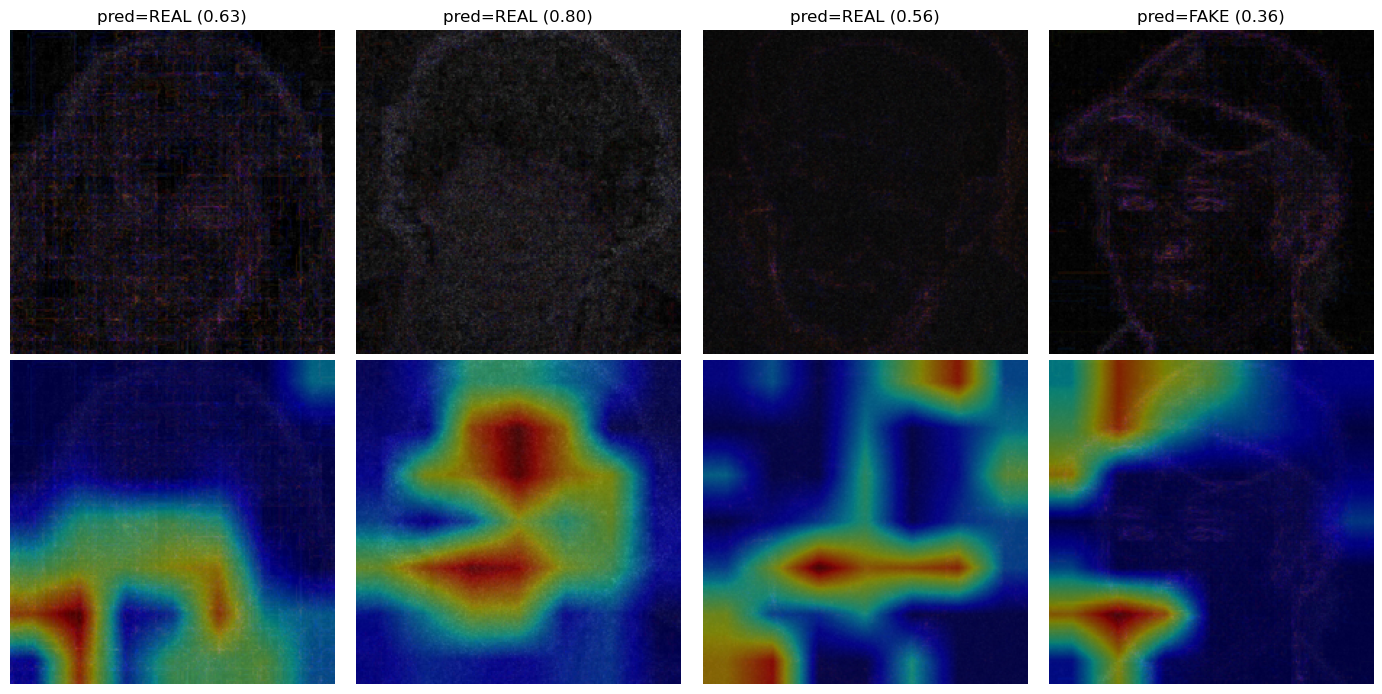

In [21]:
import cv2

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i in range(4):
    img_np = X_test[i]
    heatmap, pred = grad_cam(model, img_np)
    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)

    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"pred={'REAL' if pred >= 0.5 else 'FAKE'} ({pred:.2f})")
    axes[0, i].axis("off")

    axes[1, i].imshow(img_np)
    axes[1, i].imshow(heatmap_resized, cmap="jet", alpha=0.5)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Phase 9: Save the Model
Goal: export the trained model so the upcoming app can load it without retraining. We save the full model (architecture + weights) in Keras's native format.

In [22]:
model.save("real_vs_fake_face_model.keras")
print("Saved")

Saved


## Phase 10: Findings & Conclusion

**What I investigated:**
Whether a CNN can detect subtle, localized face manipulations (Photoshop splices), and what it actually takes to make that work.

- **Iteration 1:** frozen MobileNetV2 on raw pixels → ~50% accuracy (chance). Generic ImageNet features don't capture fine-grained blending artifacts.
- **Iteration 2:** fine-tuned the last 30 layers on raw pixels → still weak (~51-58%), slow to converge, biased toward one class.
- **Iteration 3:** switched input from raw pixels to Error Level Analysis (ELA) maps, which surface JPEG compression mismatches from the splice. This was the change that actually worked.

**Results (fine-tuned to convergence, best checkpoint restored via early stopping):**
- Overall test accuracy: **65%** (FAKE precision 0.60 / recall 0.75, REAL precision 0.72 / recall 0.56)
- Accuracy by fake difficulty: easy 71.4% (n=35), mid 78.9% (n=76), hard 69.7% (n=33), real 55.8% (n=163)
- Train accuracy climbed to ~76% while val accuracy plateaued around 63-64% and val loss ticked slightly upward late in training — early signs of overfitting, expected given the dataset is only ~2,000 images. `restore_best_weights=True` means the reported test numbers come from the best checkpoint, not the final epoch's weights.
- The model is now noticeably better at catching fakes across all difficulty levels than it is at correctly recognizing real, unaltered faces (56% real recall vs 75% fake recall) — i.e. it's biased toward flagging things as manipulated. That's a meaningfully different failure mode than an earlier, shorter training run, which instead struggled more with easy fakes specifically. With a test set this small (33-76 images per difficulty bucket), some of that difference is run-to-run variance, not a stable pattern — worth stating honestly rather than picking whichever story sounds better.